# 08 - Modélisation du DPE regroupé

Ce notebook entraîne et compare plusieurs modèles de classification
pour prédire l'étiquette **DPE regroupée (A_B, C, D, E, F_G)** à partir
des variables explicatives issues du dataset nettoyé et enrichi.

Le but est de :
- Comparer rapidement plusieurs modèles avec LazyPredict
- Sélectionner le meilleur modèle
- L’évaluer finement (F1, accuracy, matrice de confusion)
- Étudier l’importance des features


In [1]:
import pandas as pd

# Charger le dataset final
df = pd.read_csv("../data/Prepared/prepared_dpe_regroupe_final.csv")
print("Données chargées :", df.shape)

df["etiquette_dpe_regroupee"].value_counts(normalize=True)

Données chargées : (358302, 27)


etiquette_dpe_regroupee
C      0.384542
D      0.312538
E      0.169896
F_G    0.080061
A_B    0.052964
Name: proportion, dtype: float64

In [2]:
df = df.drop(columns=["annee_construction", "surface_habitable_logement"], errors="ignore")

### 01. split + typage colonnes

In [3]:
from sklearn.model_selection import train_test_split

target = "etiquette_dpe_regroupee"
X = df.drop(columns=[target])
y = df[target]

# Types de colonnes
num_cols = X.select_dtypes(include=["number", "float", "int"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f" Nb colonnes numériques: {len(num_cols)}")
print(f" Nb colonnes catégorielles: {len(cat_cols)}")

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Shapes — X_train, X_test:", X_train.shape, X_test.shape)
print("Shapes — y_train, y_test:", y_train.shape, y_test.shape)

# Sanity check: répartition des classes train/test
print("\n Répartition des classes (train) :")
print(y_train.value_counts(normalize=True).round(3))
print("\n RRépartition des classes (test) :")
print(y_test.value_counts(normalize=True).round(3))

 Nb colonnes numériques: 12
 Nb colonnes catégorielles: 12
Shapes — X_train, X_test: (286641, 24) (71661, 24)
Shapes — y_train, y_test: (286641,) (71661,)

 Répartition des classes (train) :
etiquette_dpe_regroupee
C      0.385
D      0.313
E      0.170
F_G    0.080
A_B    0.053
Name: proportion, dtype: float64

 RRépartition des classes (test) :
etiquette_dpe_regroupee
C      0.385
D      0.313
E      0.170
F_G    0.080
A_B    0.053
Name: proportion, dtype: float64


### 02. Préprocesseur combiné

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Préprocesseur : normalisation + encodage
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# Test de transformation (juste pour vérifier que ça fonctionne)
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Transformation OK")
print("X_train_ready shape:", X_train_ready.shape)
print("X_test_ready shape:", X_test_ready.shape)

Transformation OK
X_train_ready shape: (286641, 80)
X_test_ready shape: (71661, 80)


### 03. RandomForestClassifier

Rapport de classification :
              precision    recall  f1-score   support

         A_B      0.973     0.933     0.953      3795
           C      0.976     0.972     0.974     27557
           D      0.953     0.965     0.959     22397
           E      0.956     0.955     0.956     12175
         F_G      0.970     0.966     0.968      5737

    accuracy                          0.965     71661
   macro avg      0.966     0.958     0.962     71661
weighted avg      0.965     0.965     0.965     71661



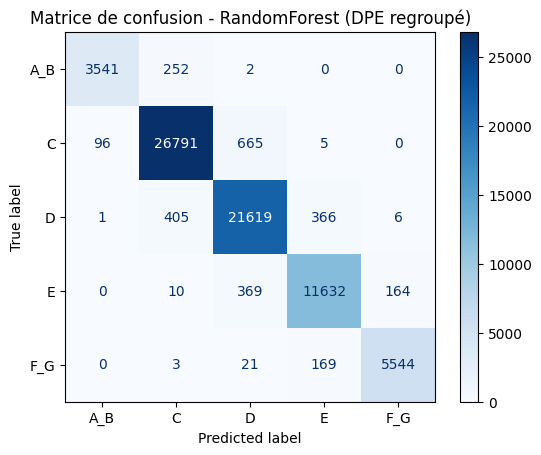

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Pipeline complet = préprocesseur + modèle
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced", 
        n_jobs=-1
    ))
])

# Entraînement
rf_model.fit(X_train, y_train)

# Prédiction
y_pred = rf_model.predict(X_test)

# Évaluation
print("Rapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

# Matrice de confusion
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues")
plt.title("Matrice de confusion - RandomForest (DPE regroupé)")
plt.show()

### 04. Importance des variables (RandomForest)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer le modèle entraîné (déjà dans rf_model)
rf = rf_model.named_steps["classifier"]

# Récupérer les noms de features après transformation
# Récupérer les noms des features catégorielles encodées
encoder = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_cols = encoder.get_feature_names_out(cat_cols)

# Concaténer les noms des features finales
all_features = np.concatenate([num_cols, encoded_cat_cols])

# Construire le DataFrame des importances
feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Afficher les 20 plus importantes
top_features = feat_imp.head(20)
print("\t Top 20 features les plus importantes :")
display(top_features)

	 Top 20 features les plus importantes :


,Feature,Importance
8,conso_m2,0.466198
2,conso_ecs_ep,0.065994
10,volume_logement,0.054349
9,anciennete,0.048484
37,qualite_isolation_murs_INSUFFISANTE,0.038622
7,code_postal_ban,0.034785
39,qualite_isolation_murs_TRÈS BONNE,0.021156
64,qualite_isolation_menuiseries_TRÈS BONNE,0.019034
5,hauteur_sous_plafond,0.018472
78,classe_annee_construction_apres_2012,0.017202


### 05. Visualisations centrées sur le modèle RandomForest

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20176\3919462063.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_df, x="Classe", y="F1-score", palette="viridis")


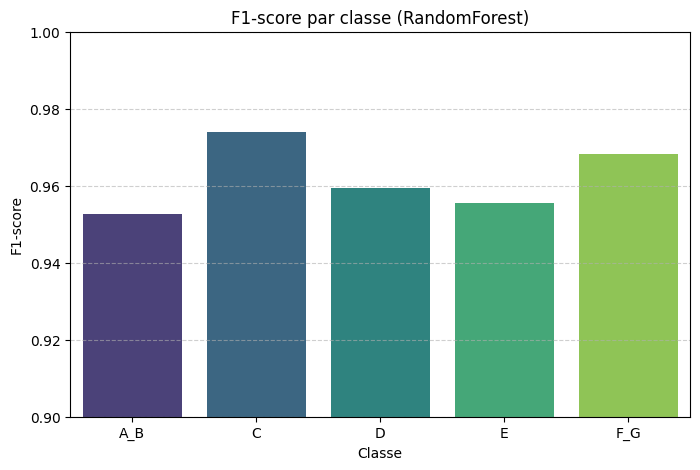

,Classe,Precision,Recall,F1-score,Support
0,A_B,0.973,0.933,0.953,3795
1,C,0.976,0.972,0.974,27557
2,D,0.953,0.965,0.959,22397
3,E,0.956,0.955,0.956,12175
4,F_G,0.970,0.966,0.968,5737


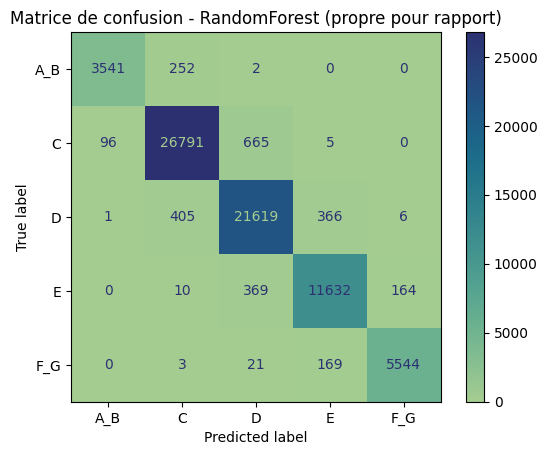

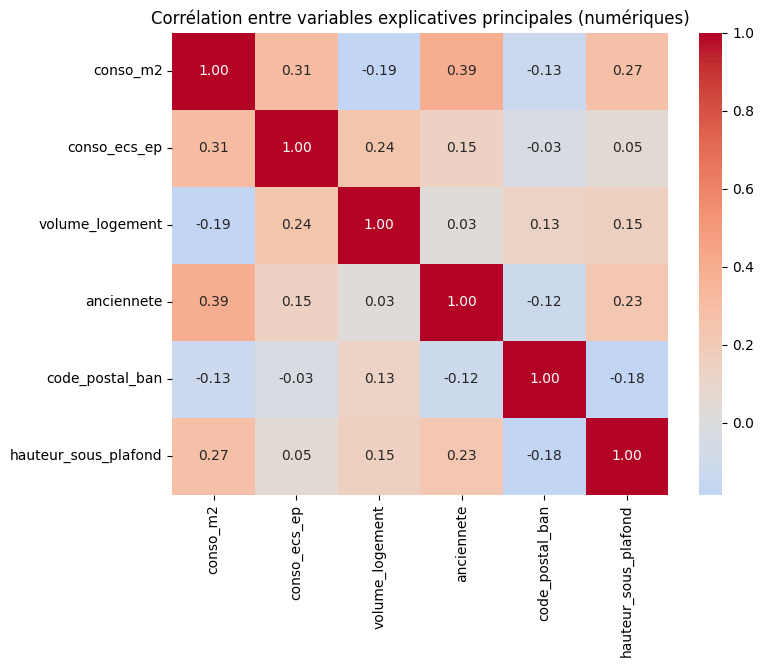

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support

# Répartition des performances par classe (precision, recall, F1)
labels = rf_model.classes_
precision, recall, f1, support = precision_recall_fscore_support(y_test, rf_model.predict(X_test))

perf_df = pd.DataFrame({
    "Classe": labels,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
}).sort_values("Classe")

plt.figure(figsize=(8,5))
sns.barplot(data=perf_df, x="Classe", y="F1-score", palette="viridis")
plt.title("F1-score par classe (RandomForest)")
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

display(perf_df.round(3))


ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, cmap="crest", colorbar=True
)
plt.title("Matrice de confusion - RandomForest (propre pour rapport)")
plt.show()


# Corrélation des principales variables explicatives (analyse de structure)
top_vars = feat_imp.head(10)["Feature"].tolist()
num_top = [v for v in top_vars if v in df.columns and np.issubdtype(df[v].dtype, np.number)]

if len(num_top) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_top].corr(), cmap="coolwarm", annot=True, fmt=".2f", center=0)
    plt.title("Corrélation entre variables explicatives principales (numériques)")
    plt.show()
else:
    print("Pas assez de variables numériques dans le top 10 pour une matrice de corrélation.")


### 06. Corrélation avec la variable cible

In [10]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Encoder la cible (étiquette DPE regroupée)
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["etiquette_dpe_regroupee"])

# Sélectionner les colonnes numériques
num_cols_corr = df.select_dtypes(include=["number", "float", "int"]).columns.tolist()

# Corrélation
corr_matrix = df[num_cols_corr].corr(numeric_only=True)["target_encoded"].sort_values(ascending=False)

# Affichage top variables corrélées à la cible
print("Corrélation avec la cible (etiquette_dpe_regroupee):")
display(corr_matrix.head(5))
display(corr_matrix.tail(5))

Corrélation avec la cible (etiquette_dpe_regroupee):


target_encoded          1.000000
conso_m2                0.873467
anciennete              0.416261
conso_ecs_ep            0.292128
hauteur_sous_plafond    0.279830
Name: target_encoded, dtype: float64

volume_logement         -0.101698
code_postal_ban         -0.104296
score_isolation_moyen   -0.217236
code_region_ban               NaN
code_departement_ban          NaN
Name: target_encoded, dtype: float64

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20176\2929689134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_matrix.values, y=corr_matrix.index, palette="coolwarm")


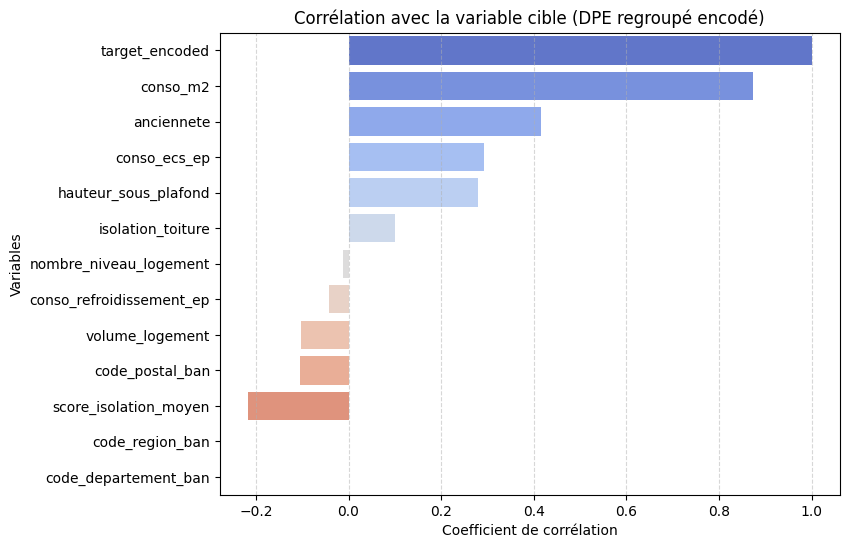

In [11]:
# Visualisation
plt.figure(figsize=(8,6))
sns.barplot(x=corr_matrix.values, y=corr_matrix.index, palette="coolwarm")
plt.title("Corrélation avec la variable cible (DPE regroupé encodé)")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

Pour que le modèle soit vraiment **prédictif** et non “explicatif”, on retire :
- conso_m2
- conso_ecs_ep

#### Variables retenues pour le modèle prédictif (version Streamlit / API)

L’objectif de ce modèle est de **prédire l’étiquette DPE regroupée** à partir des **caractéristiques physiques et thermiques du logement**,  
sans utiliser de mesures directes de consommation énergétique (`conso_m2`, `conso_ecs_ep`, etc.).

| Catégorie | Variables | Description |
|:-----------|:-----------|:-------------|
| 🏠 **Structure du logement** | `volume_logement`<br>`hauteur_sous_plafond`<br>`nombre_niveau_logement`<br>`anciennete` | Taille, volume et âge du logement |
| ❄️ **Isolation thermique** | `isolation_toiture`<br>`score_isolation_moyen`<br>`qualite_isolation_murs`<br>`qualite_isolation_menuiseries` | Niveau et qualité d’isolation thermique |
| 🔌 **Énergie et systèmes** | `type_energie_principale_chauffage`<br>`energie_regroupee`<br>`type_logement_source`<br>`classe_annee_construction` | Type d’énergie, source de chauffage et période de construction |

Ces variables sont **déclaratives et compréhensibles pour un utilisateur final**,  
ce qui permet de créer un **formulaire Streamlit simple** et un modèle **totalement prédictif**,  
indépendant des données de consommation déjà mesurées.


### 07. Nettoyage et sélection des variables finales

In [12]:
import pandas as pd

df = pd.read_csv("../data/Prepared/prepared_dpe_regroupe_final.csv")

# Variables à conserver (celles choisies pour le modèle prédictif)
selected_features = [
    "volume_logement",
    "hauteur_sous_plafond",
    "nombre_niveau_logement",
    "anciennete",
    "isolation_toiture",
    "score_isolation_moyen",
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage",
    "energie_regroupee",
    "type_logement_source",
    "classe_annee_construction"
]

target = "etiquette_dpe_regroupee"

# Filtrer le DataFrame
df_pred = df[selected_features + [target]].copy()


print("Dataset nettoyé et réduit :", df_pred.shape)
print("Variables conservées :", list(df_pred.columns))

Dataset nettoyé et réduit : (358302, 13)
Variables conservées : ['volume_logement', 'hauteur_sous_plafond', 'nombre_niveau_logement', 'anciennete', 'isolation_toiture', 'score_isolation_moyen', 'qualite_isolation_murs', 'qualite_isolation_menuiseries', 'type_energie_principale_chauffage', 'energie_regroupee', 'type_logement_source', 'classe_annee_construction', 'etiquette_dpe_regroupee']


### 08. Modèle prédictif final

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Séparation X / y
target = "etiquette_dpe_regroupee"
X = df_pred.drop(columns=[target])
y = df_pred[target]

# Identifier types de colonnes
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Colonnes numériques : {num_cols}")
print(f"Colonnes catégorielles : {cat_cols}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Jeu d'entraînement : {X_train.shape}, test : {X_test.shape}")


Colonnes numériques : ['volume_logement', 'hauteur_sous_plafond', 'nombre_niveau_logement', 'anciennete', 'isolation_toiture', 'score_isolation_moyen']
Colonnes catégorielles : ['qualite_isolation_murs', 'qualite_isolation_menuiseries', 'type_energie_principale_chauffage', 'energie_regroupee', 'type_logement_source', 'classe_annee_construction']
Jeu d'entraînement : (286641, 12), test : (71661, 12)


In [14]:
# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline RandomForest
rf_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
rf_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['volume_logement',
                                                   'hauteur_sous_plafond',
                                                   'nombre_niveau_logement',
                                                   'anciennete',
                                                   'isolation_toiture',
                                                   'score_isolation_moyen']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['qualite_isolation_murs',
                                                   'qualite_isolation_menuiseries',
                                                   'type_energie_principale_chauffage',
                                                   'energie_regroupee',
                                                   'type_logement_source',
                                                   'classe_annee_construction'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

Rapport de classification :
              precision    recall  f1-score   support

         A_B      0.691     0.822     0.751      3795
           C      0.811     0.775     0.793     27557
           D      0.627     0.606     0.616     22397
           E      0.485     0.502     0.493     12175
         F_G      0.391     0.447     0.417      5737

    accuracy                          0.652     71661
   macro avg      0.601     0.630     0.614     71661
weighted avg      0.658     0.652     0.654     71661



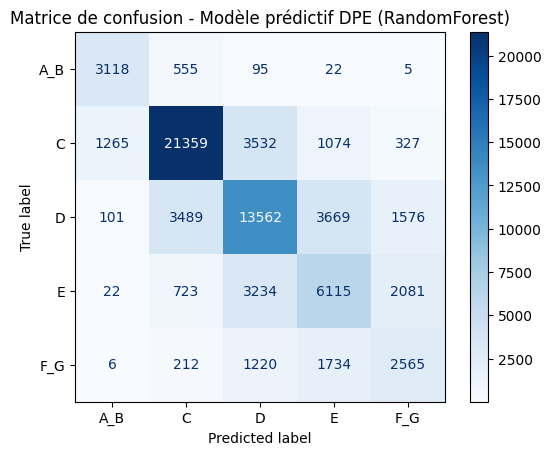

In [15]:
# Évaluation
y_pred = rf_final.predict(X_test)
print("Rapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

# Matrice de confusion
ConfusionMatrixDisplay.from_estimator(rf_final, X_test, y_test, cmap="Blues")
plt.title("Matrice de confusion - Modèle prédictif DPE (RandomForest)")
plt.show()

### 09. Visualisations avancées RandomForest

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20176\4030285369.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


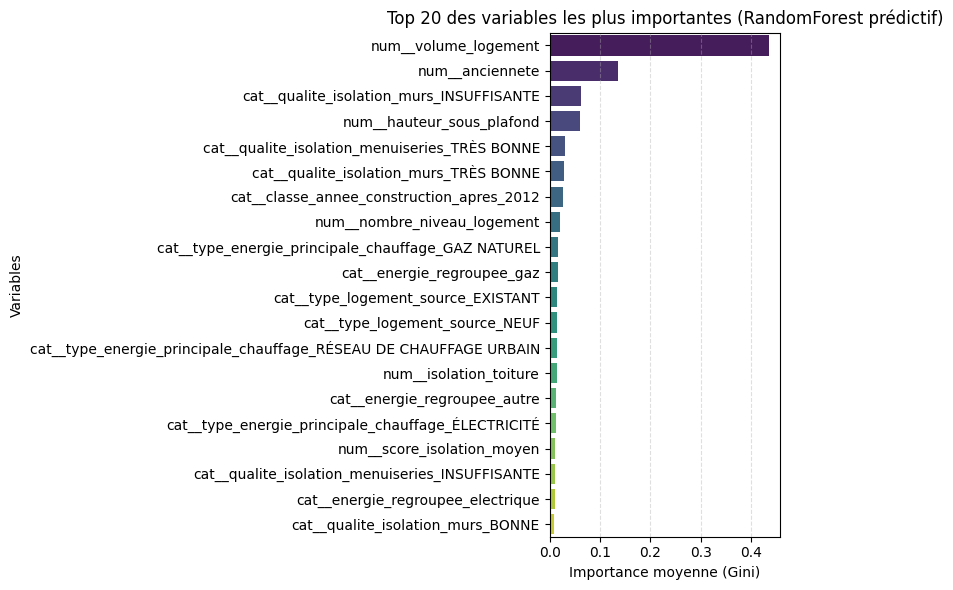

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20176\4030285369.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")


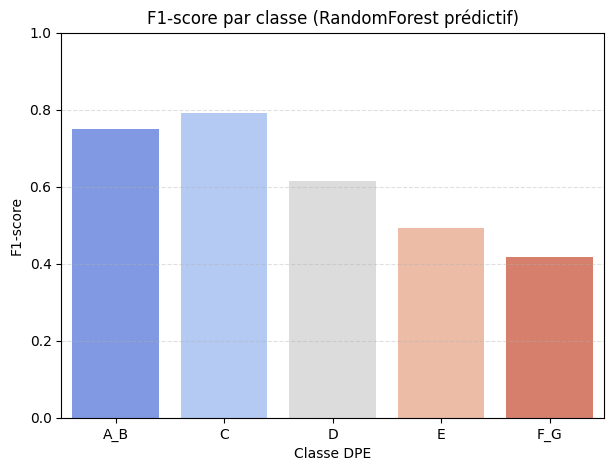

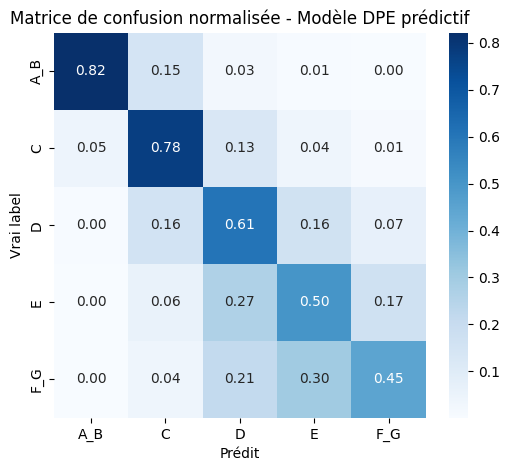

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.inspection import permutation_importance

# 1️⃣ Importance des features
importances = rf_final.named_steps["classifier"].feature_importances_
feature_names = rf_final.named_steps["preprocessor"].get_feature_names_out()
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Top 20 des variables les plus importantes (RandomForest prédictif)")
plt.xlabel("Importance moyenne (Gini)")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# 2️⃣ Erreurs de prédiction par classe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])

plt.figure(figsize=(7,5))
sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")
plt.title("F1-score par classe (RandomForest prédictif)")
plt.ylabel("F1-score")
plt.xlabel("Classe DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


# 3️⃣ Matrice de confusion normalisée
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=rf_final.classes_, yticklabels=rf_final.classes_)
plt.title("Matrice de confusion normalisée - Modèle DPE prédictif")
plt.xlabel("Prédit")
plt.ylabel("Vrai label")
plt.show()



##### Synthèse visuelle du modèle prédictif DPE (RandomForest)

| Graphique | Interprétation principale |
|------------|---------------------------|
| **Importance des variables** | Le modèle s’appuie surtout sur la **taille (volume)** et l’**ancienneté** du logement, puis sur la **qualité d’isolation** et le **type d’énergie**. |
| **F1-score par classe** | Bonnes performances pour les classes **A_B** et **C**, plus de confusions entre **D–E–F_G**, souvent voisines thermiquement. |
| **Matrice de confusion** | Peu d’erreurs extrêmes (A_B ↔ F_G). Le modèle reproduit correctement la hiérarchie énergétique des logements. |

- Ces résultats montrent que le modèle capture les **tendances physiques réelles** du DPE, tout en restant **utilisable sans données de consommation**.


In [17]:
# Extraire le préprocesseur
preprocessor = rf_final.named_steps["preprocessor"]

# Récupérer les noms de features après transformation (encodage + scaling)
feature_names = preprocessor.get_feature_names_out()

# Afficher proprement
print("🔹 Nombre total de variables utilisées :", len(feature_names))
print("\n🔹 Liste complète des variables d’entrée du modèle :\n")
for f in feature_names:
    print(f)

🔹 Nombre total de variables utilisées : 39

🔹 Liste complète des variables d’entrée du modèle :

num__volume_logement
num__hauteur_sous_plafond
num__nombre_niveau_logement
num__anciennete
num__isolation_toiture
num__score_isolation_moyen
cat__qualite_isolation_murs_BONNE
cat__qualite_isolation_murs_INSUFFISANTE
cat__qualite_isolation_murs_MOYENNE
cat__qualite_isolation_murs_TRÈS BONNE
cat__qualite_isolation_menuiseries_BONNE
cat__qualite_isolation_menuiseries_INSUFFISANTE
cat__qualite_isolation_menuiseries_MOYENNE
cat__qualite_isolation_menuiseries_TRÈS BONNE
cat__type_energie_principale_chauffage_BOIS – BÛCHES
cat__type_energie_principale_chauffage_BOIS – GRANULÉS (PELLETS) OU BRIQUETTES
cat__type_energie_principale_chauffage_BOIS – PLAQUETTES D’INDUSTRIE
cat__type_energie_principale_chauffage_BOIS – PLAQUETTES FORESTIÈRES
cat__type_energie_principale_chauffage_CHARBON
cat__type_energie_principale_chauffage_FIOUL DOMESTIQUE
cat__type_energie_principale_chauffage_GAZ NATUREL
cat__type_

In [ ]:
import joblib
import json
import os

# Dossier de sauvegarde
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

# Fichiers de sortie
model_path = os.path.join(save_dir, "rf_dpe_predictif.joblib")
features_path = os.path.join(save_dir, "rf_dpe_features.json")

# 1. Sauvegarde du pipeline complet
joblib.dump(rf_final, model_path)
print(f" Modèle sauvegardé : {model_path}")

# 2. Sauvegarde des noms de features
feature_names = rf_final.named_steps["preprocessor"].get_feature_names_out().tolist()
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print(f" Liste des variables sauvegardée : {features_path}")


 Modèle sauvegardé : ../models\rf_dpe_predictif.joblib
 Liste des variables sauvegardée : ../models\rf_dpe_features.json


In [8]:
import pandas as pd
import joblib
import time

# Charger le modèle UNE FOIS
model = joblib.load("../models/rf_dpe_predictif.joblib")

# Exemple
data_input = pd.DataFrame([{
    "volume_logement": 250,
    "hauteur_sous_plafond": 2.6,
    "nombre_niveau_logement": 2,
    "anciennete": 1,
    "isolation_toiture": 3,
    "score_isolation_moyen": 2.5,
    "qualite_isolation_murs": "MOYENNE",
    "qualite_isolation_menuiseries": "BONNE",
    "type_energie_principale_chauffage": "GAZ NATUREL",
    "energie_regroupee": "gaz",
    "type_logement_source": "EXISTANT",
    "classe_annee_construction": "1975_1989"
}])

start = time.time()
prediction = model.predict(data_input)
print(" Étiquette DPE prédite :", prediction[0])
print(" Temps de prédiction :", round(time.time() - start, 3), "secondes")


 Étiquette DPE prédite : C
 Temps de prédiction : 0.485 secondes
